In [ ]:
# ==========================================================
# Notebook 07
#
# Biologically Weighted Patient Communication Matrix
#
# Goal
# ----
# Improve patient communication features by incorporating
# cell-type abundance while maintaining one feature per
# ligand–receptor interaction.
#
# Output
# ------
# weighted_patient_communication_matrix.csv
# ==========================================================

In [1]:
import warnings
warnings.filterwarnings("ignore")

import scanpy as sc
import pandas as pd
import numpy as np
from tqdm import tqdm

import liana.resource as lr

In [12]:
adata = sc.read_h5ad(
    "data/IntegratedAtlas.h5ad",
    backed="r"
)

adata

AnnData object with n_obs × n_vars = 621200 × 37389 backed at 'data\\IntegratedAtlas.h5ad'
    obs: 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'grade', 'author_cell_type', 'batch', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'default_embedding', 'is_pre_analysis', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_rpca', 'X_umap'

In [13]:
lr_db = lr.select_resource("consensus")

print(len(lr_db))
lr_db.head()

4624


,ligand,receptor
0,LGALS9,PTPRC
1,LGALS9,MET
2,LGALS9,CD44
3,LGALS9,LRP1
4,LGALS9,CD47


In [14]:
donors = adata.obs["donor_id"].unique().tolist()

print(len(donors))

138


In [ ]:
def build_weighted_patient_vector(
    adata,
    donor,
    lr_db,
):
    
    # -------------------------
    # Load donor into memory
    # -------------------------
    
    ad = adata[
        adata.obs["donor_id"] == donor
    ].to_memory()
    
    
    # -------------------------
    # Gene symbols
    # -------------------------
    
    ad.var_names = ad.var["feature_name"].astype(str)
    ad.var_names_make_unique()
    
    
    
    sc.pp.normalize_total(
        ad,
        target_sum=1e4
    )
    
    sc.pp.log1p(ad)
    
    
    
    expr = ad.to_df()
    expr["cell_type"] = ad.obs["cell_type"].values
    
    mean_expr = expr.groupby("cell_type").mean()
    
    
    
    abundance = (
        ad.obs["cell_type"]
        .value_counts(normalize=True)
    )
    
    
    
    scores = {}
    
    for _, row in lr_db.iterrows():
        
        lig = row["ligand"]
        rec = row["receptor"]
        
        if (
            lig not in mean_expr.columns
            or
            rec not in mean_expr.columns
        ):
            continue
        
        score = 0
        
        for ct in mean_expr.index:
            
            score += (
                abundance[ct]
                *
                mean_expr.loc[ct, lig]
                *
                mean_expr.loc[ct, rec]
            )
        
        scores[f"{lig}→{rec}"] = score
        
    return pd.Series(scores)

In [16]:
patient_vectors = {}

for donor in tqdm(donors):

    patient_vectors[donor] = build_weighted_patient_vector(
        adata,
        donor,
        lr_db
    )

100%|██████████| 138/138 [16:29<00:00,  7.17s/it]


In [17]:
communication_matrix = (
    pd.DataFrame(patient_vectors)
      .T
      .fillna(0)
)

communication_matrix.head()

,LGALS9→PTPRC,LGALS9→MET,LGALS9→CD44,LGALS9→LRP1,LGALS9→CD47,LGALS9→PTPRK,LGALS9→COLEC12,LGALS9→HAVCR2,LGALS9→MRC2,DLL1→NOTCH1,...,BMP6→AMHR2,GDF11→ACTR2,GDF1→ACTR2,INHBA→ACTR2,BMP7→ACTR2,BMP2→ACTR2,BMP15→ACTR2,CSF1→CSF3R,IL36G→IFNAR1,IL36G→IFNAR2
wu_natgen_CID3586,0.121846,0.005813,0.114943,0.016198,0.064361,0.017506,0.005438,0.015871,0.007528,0.002321,...,0.000000e+00,0.006296,0.0,0.008336,0.000375,0.004882,0.0,0.003157,0.000000,0.00000
wu_natgen_CID3921,0.256975,0.021285,0.350640,0.124034,0.204259,0.052583,0.006282,0.125498,0.030848,0.008589,...,0.000000e+00,0.009099,0.0,0.053843,0.045780,0.012879,0.0,0.007845,0.000000,0.00000
wu_natgen_CID45171,0.132339,0.001740,0.115007,0.013216,0.067992,0.007503,0.002754,0.016397,0.004081,0.000639,...,0.000000e+00,0.037818,0.0,0.014822,0.019084,0.000919,0.0,0.000649,0.000000,0.00000
wu_natgen_CID3838,0.750411,0.014521,0.732003,0.271448,0.437159,0.043529,0.128353,0.306112,0.122696,0.020450,...,8.710662e-07,0.332394,0.0,0.409445,0.017065,0.071029,0.0,0.023655,0.000172,0.00014
wu_natgen_CID4066,0.087855,0.011659,0.102363,0.073121,0.100798,0.049065,0.012883,0.018976,0.048334,0.009714,...,9.906333e-08,0.013957,0.0,0.082266,0.013887,0.012891,0.0,0.003100,0.000000,0.00000


In [18]:
print("Patients :", communication_matrix.shape[0])
print("Features :", communication_matrix.shape[1])

print()

print("Missing values:",
      communication_matrix.isna().sum().sum())

print()

print("Zero fraction:",
      (communication_matrix==0).mean().mean())

Patients : 138
Features : 3489

Missing values: 0

Zero fraction: 0.377492824238497


In [19]:
feature_variance = communication_matrix.var()

feature_variance.sort_values(
    ascending=False
).head(20)

HLA-B→CD3D      1.230931
HMGB1→CXCR4     1.175334
VIM→CD44        1.150386
TIMP1→CD63      0.922302
LGALS1→ITGB1    0.705506
HLA-A→APLP2     0.444354
CD99→CD81       0.427109
HLA-B→CD8A      0.384015
MDK→NCL         0.377310
HLA-C→CD8A      0.364789
HLA-A→CD8A      0.353807
PLAU→ST14       0.350025
HLA-B→KLRD1     0.347873
LGALS1→PTPRC    0.343687
ARF1→PLD2       0.321487
APP→CD74        0.303209
TGFB1→CXCR4     0.292697
PKM→CD44        0.288356
LUM→ITGB1       0.273560
SPINT1→ST14     0.266400
dtype: float64

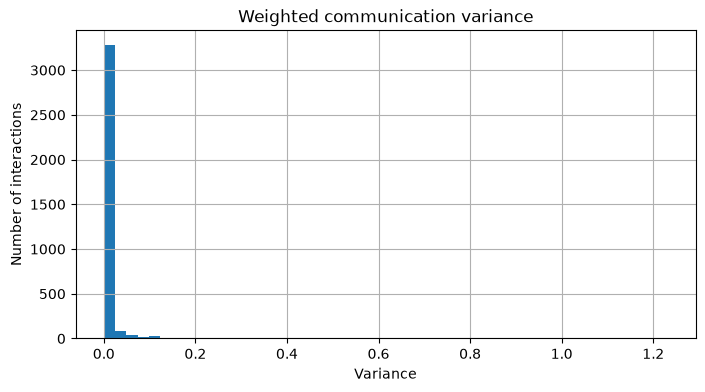

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

feature_variance.hist(
    bins=50
)

plt.xlabel("Variance")

plt.ylabel("Number of interactions")

plt.title(
    "Weighted communication variance"
)

plt.show()

In [22]:
communication_matrix.to_csv(
    "data/outputs/weighted_patient_communication_matrix.csv"
)

print(communication_matrix.shape)

(138, 3489)


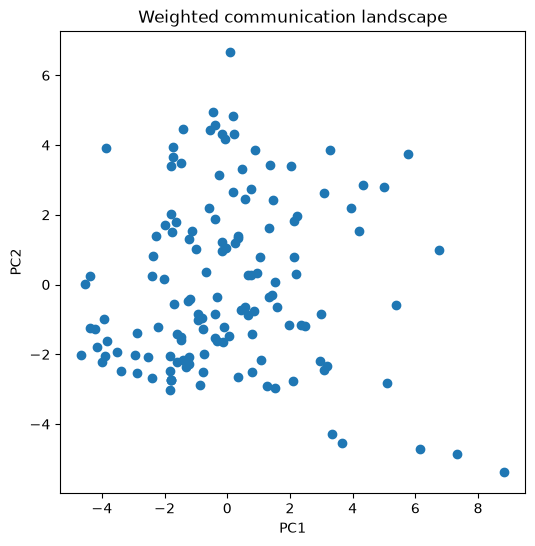

[0.22237209 0.20672413]


In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X = pca.fit_transform(
    communication_matrix
)

plt.figure(figsize=(6,6))

plt.scatter(
    X[:,0],
    X[:,1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Weighted communication landscape"
)

plt.show()

print(pca.explained_variance_ratio_)